Saving dataset3.zip to dataset3.zip
First 5 rows:
   Daily Time Spent on Site  Age  Area Income  Daily Internet Usage  \
0                     68.95   35     61833.90                256.09   
1                     80.23   31     68441.85                193.77   
2                     69.47   26     59785.94                236.50   
3                     74.15   29     54806.18                245.89   
4                     68.37   35     73889.99                225.58   

                           Ad Topic Line            City  Male     Country  \
0     Cloned 5thgeneration orchestration     Wrightburgh     0     Tunisia   
1     Monitored national standardization       West Jodi     1       Nauru   
2       Organic bottom-line service-desk        Davidton     0  San Marino   
3  Triple-buffered reciprocal time-frame  West Terrifurt     1       Italy   
4          Robust logistical utilization    South Manuel     0     Iceland   

             Timestamp  Clicked on Ad  
0  2016-03-27 

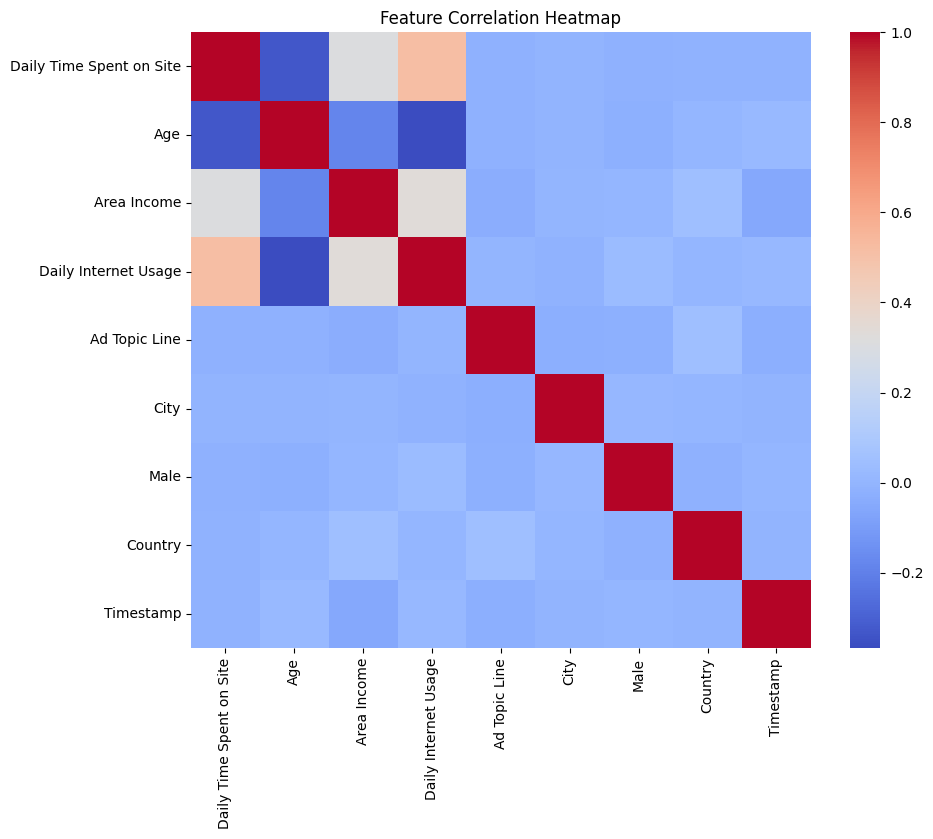


Model Coefficients:
[[-2.59774039  1.32177122 -1.65085983 -2.85494319  0.23641942 -0.32247184
  -0.32909244 -0.15851342  0.23296808]]
Intercept: [1.55373317]

K-Fold Cross Validation Scores:
[0.95  0.98  0.98  0.95  0.975]
Average CV Accuracy: 0.967

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.94        89
           1       0.96      0.95      0.95       111

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200



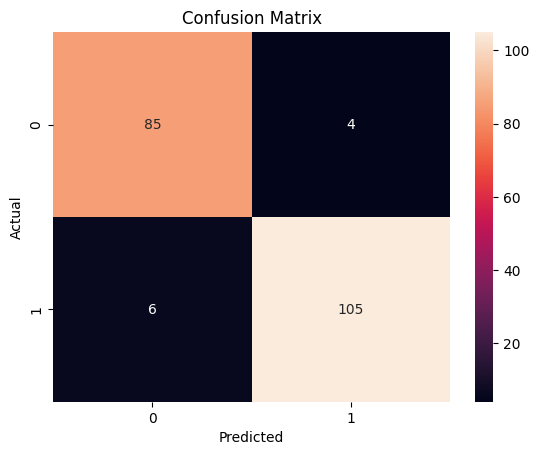

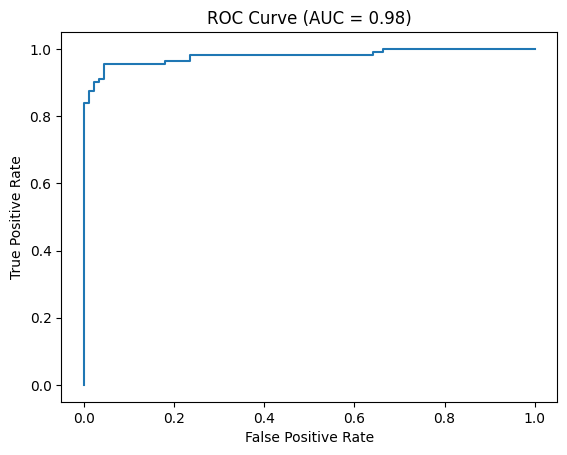

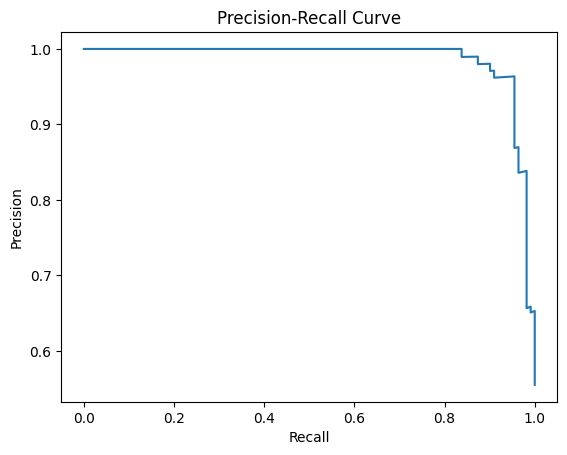

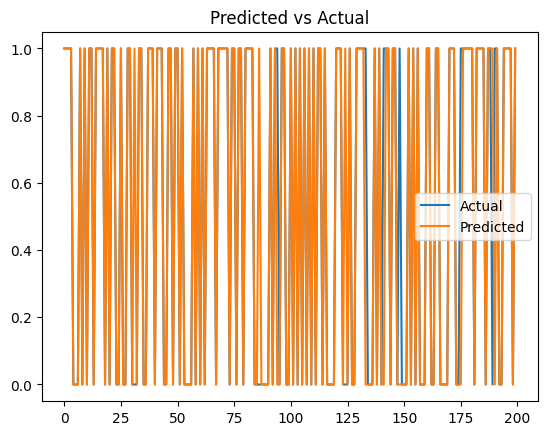

In [ ]:
# ==========================================
# EXPERIMENT 3 – LOGISTIC REGRESSION
# Advertisement Click Prediction
# ==========================================

# 1️⃣ Import Libraries
import zipfile
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve

# 2️⃣ Upload dataset zip file
from google.colab import files
uploaded = files.upload()

zip_path = list(uploaded.keys())[0]
extract_path = "ad_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# 3️⃣ Locate CSV file
csv_file = None
for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.endswith(".csv"):
            csv_file = os.path.join(root, file)

# 4️⃣ Load Dataset
df = pd.read_csv(csv_file)

# ==========================================
# a) Dataset Information
# ==========================================
print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())


# ==========================================
# b) EDA & Preprocessing
# ==========================================

# Handle missing values (if any)
df = df.dropna()

# Encode categorical variables
for column in df.columns:
    if df[column].dtype == 'object':
        le = LabelEncoder()
        df[column] = le.fit_transform(df[column])

# Separate features & target
target_column = df.columns[-1]  # Assuming last column is target
X = df.drop(target_column, axis=1)
y = df[target_column]

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# c) Correlation Heatmap
# ==========================================
plt.figure(figsize=(10,8))
sns.heatmap(pd.DataFrame(X_scaled, columns=X.columns).corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


# ==========================================
# d) Train-Test Split (80:20)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("\nModel Coefficients:")
print(model.coef_)
print("Intercept:", model.intercept_)


# ==========================================
# e) K-Fold Cross Validation
# ==========================================
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_scaled, y, cv=kf)

print("\nK-Fold Cross Validation Scores:")
print(cv_scores)
print("Average CV Accuracy:", cv_scores.mean())


# ==========================================
# f) Classification Report
# ==========================================
y_pred = model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# ==========================================
# g) Confusion Matrix
# ==========================================
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ==========================================
# ROC Curve
# ==========================================
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.title(f"ROC Curve (AUC = {roc_auc:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


# ==========================================
# Precision-Recall Curve
# ==========================================
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()


# ==========================================
# h) Predicted vs Actual Visualization
# ==========================================
plt.figure()
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Predicted vs Actual")
plt.show()
